In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

%matplotlib inline
warnings.filterwarnings('ignore')

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
from google.colab import files
import io

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
  df = pd.read_csv(io.StringIO(uploaded[fn].decode('ISO-8859-1')),
                   encoding='ISO-8859-1',
                   sep=',',
                   on_bad_lines='skip',
                   low_memory=False)

print(f"DataFrame shape: {df.shape}")
print("Column names:")
for col in df.columns:
    print(col)
print("\nFirst 5 rows:")
print(df.head())
print("File loaded successfully")

Saving online_retail_II.csv to online_retail_II.csv
User uploaded file "online_retail_II.csv" with length 94850204 bytes
DataFrame shape: (1067371, 8)
Column names:
Invoice
StockCode
Description
Quantity
InvoiceDate
Price
Customer ID
Country

First 5 rows:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:

In [3]:
print("\n--- DataFrame Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
print(df.describe())

print("\n--- Duplicate Rows ---")
print(f"Number of duplicate rows: {df.duplicated().sum()}")


--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB

--- Missing Values ---
Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

--- Summary Statistics ---
           Quantity         Price    Customer ID
count  1.067371e+06  1.067371e+06  824364.000000
mean   9.938898e+00  4

In [4]:
print(f"Shape before cleaning: {df.shape}")

# 1. Drop rows where Customer ID is missing
df.dropna(subset=['Customer ID'], inplace=True)

# 2. Drop duplicate rows
df.drop_duplicates(inplace=True)

# 3. Remove rows where Quantity is less than or equal to 0
df = df[df['Quantity'] > 0]

# 4. Remove rows where Price is less than or equal to 0
df = df[df['Price'] > 0]

# 5. Remove cancelled orders where Invoice starts with 'C'
df = df[~df['Invoice'].astype(str).str.startswith('C')]

# 6. Convert InvoiceDate to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 7. Create a new column called TotalPrice = Quantity multiplied by Price
df['TotalPrice'] = df['Quantity'] * df['Price']

# 8. Reset the index
df.reset_index(drop=True, inplace=True)

# 9. Print the shape after cleaning
print(f"Shape after cleaning: {df.shape}")

# 10. Print "Data cleaning complete"
print("Data cleaning complete")

Shape before cleaning: (1067371, 8)
Shape after cleaning: (779425, 9)
Data cleaning complete


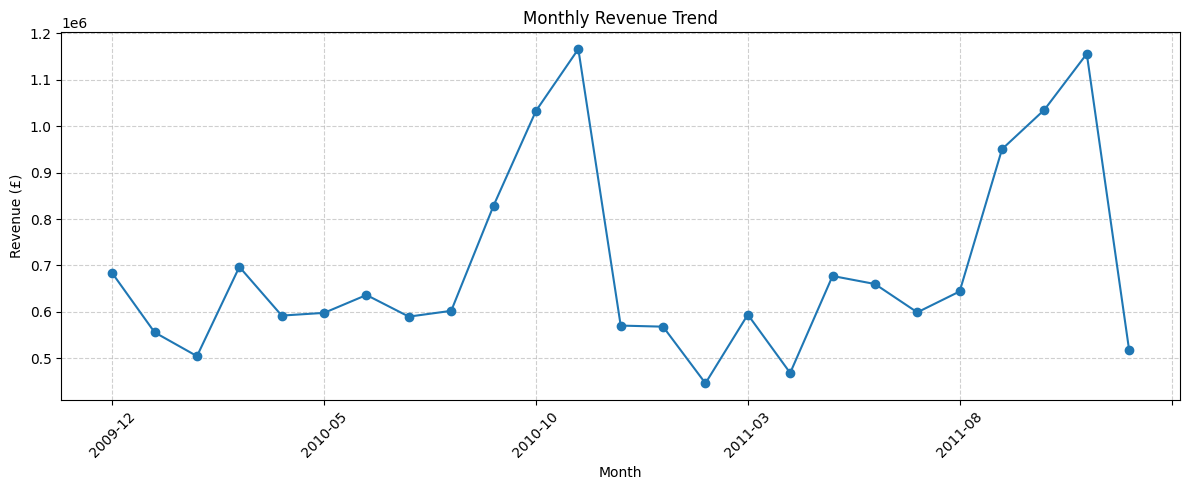


--- Top 3 Highest Revenue Months ---
YearMonth
2010-11    1166460.022
2011-11    1156205.610
2011-10    1035642.450
Name: TotalPrice, dtype: float64


In [5]:
# 1. Extract Year-Month from InvoiceDate into a new column called YearMonth
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

# 2. Group by YearMonth and sum TotalPrice to get monthly revenue
monthly_revenue = df.groupby('YearMonth')['TotalPrice'].sum()

# Convert YearMonth to string for better plotting (optional, but good practice for x-axis labels)
monthly_revenue.index = monthly_revenue.index.astype(str)

# 3. Plot a line chart
plt.figure(figsize=(12, 5))
monthly_revenue.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 4. Print the top 3 highest revenue months
print("\n--- Top 3 Highest Revenue Months ---")
print(monthly_revenue.nlargest(3))

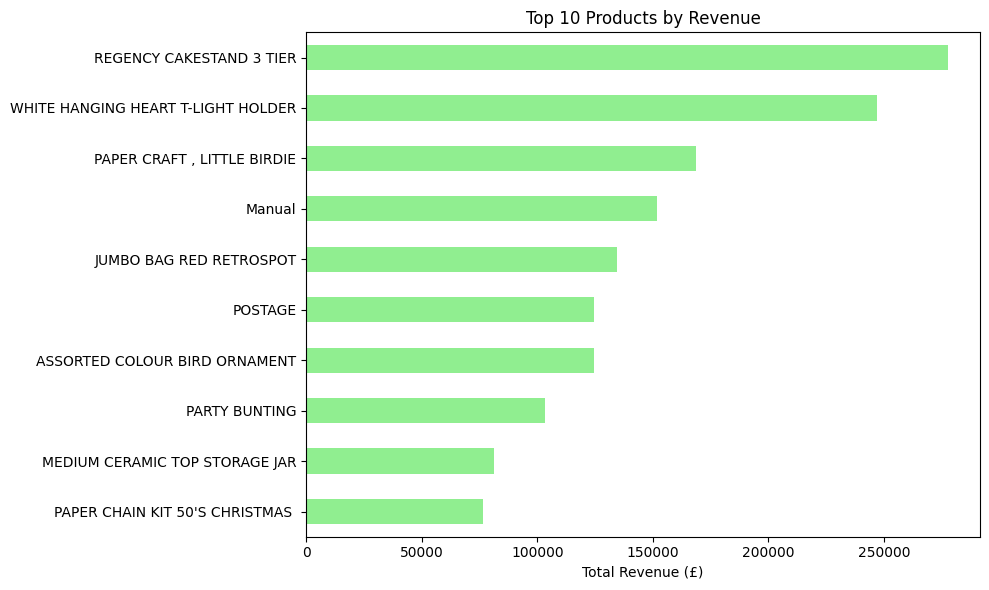


--- Top 10 Products by Revenue ---
Description
REGENCY CAKESTAND 3 TIER              277656.25
WHITE HANGING HEART T-LIGHT HOLDER    247048.01
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                151777.67
JUMBO BAG RED RETROSPOT               134307.44
POSTAGE                               124648.04
ASSORTED COLOUR BIRD ORNAMENT         124351.86
PARTY BUNTING                         103283.38
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         76598.18


In [6]:
# 1. Group by Description, sum TotalPrice, sort descending
product_revenue = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False)

# 2. Take the top 10 products
top_10_products = product_revenue.head(10)

# 3. Plot a horizontal bar chart
plt.figure(figsize=(10, 6))
top_10_products.sort_values(ascending=True).plot(kind='barh', color='lightgreen') # Sort ascending for barh to have largest at top
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue (£)')
plt.ylabel('') # Description is implicit from the bars
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Print the top 10 as a table
print("\n--- Top 10 Products by Revenue ---")
print(top_10_products.to_string())

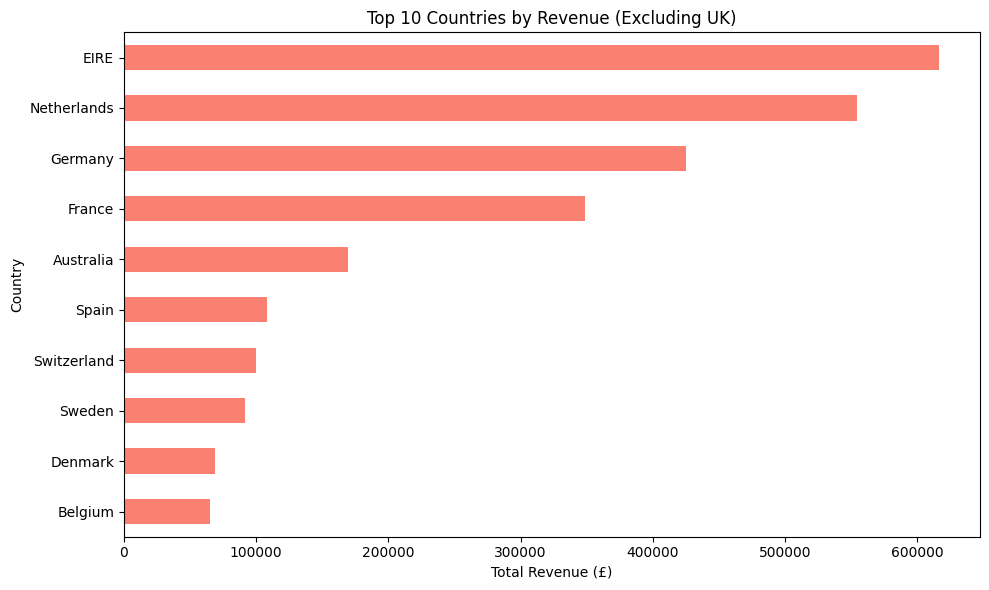


--- Top 10 Countries by Revenue (Excluding UK) ---
Country
EIRE           616570.540
Netherlands    554038.090
Germany        425019.711
France         348768.960
Australia      169283.460
Spain          108332.490
Switzerland    100061.940
Sweden          91515.820
Denmark         68580.690
Belgium         65387.820


In [7]:
# 1. Exclude rows where Country is 'United Kingdom'
revenue_by_country = df[df['Country'] != 'United Kingdom']

# 2. Group by Country, sum TotalPrice, sort descending, take top 10
revenue_by_country = revenue_by_country.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)
top_10_countries = revenue_by_country.head(10)

# 3. Plot a horizontal bar chart
plt.figure(figsize=(10, 6))
# Sort ascending for plotting barh so the largest value appears at the top
top_10_countries.sort_values(ascending=True).plot(kind='barh', color='salmon')
plt.title('Top 10 Countries by Revenue (Excluding UK)')
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

# 4. Print the results as a table
print("\n--- Top 10 Countries by Revenue (Excluding UK) ---")
print(top_10_countries.to_string())

In [8]:
import datetime as dt

# 1. Create CohortMonth column = the first purchase month for each Customer ID
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceDate'].transform('min').dt.to_period('M')

# 2. Create InvoiceMonth column = InvoiceDate floored to month (already done in step 1)

# Helper function to calculate months between two Period objects
def get_month_difference(earlier_month, later_month):
    return (later_month.year - earlier_month.year) * 12 + (later_month.month - earlier_month.month)

# 3. Create CohortIndex column = number of months between InvoiceMonth and CohortMonth
df['CohortIndex'] = df.apply(lambda row: get_month_difference(row['CohortMonth'], row['InvoiceMonth']), axis=1)

# 4. Build a cohort pivot table counting unique Customer IDs
cohort_counts = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_counts.pivot_table(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# 5. Build a retention percentage table by dividing each row by the first column (cohort size)
cohort_sizes = cohort_pivot.iloc[:, 0]
retention_table = cohort_pivot.divide(cohort_sizes, axis=0)

# Format to percentage
retention_table = retention_table.applymap(lambda x: f'{x:.2%}')

# 6. Print the first 5 rows of the retention table
print("Cohort Retention Table (first 5 cohorts, in percentage):")
print(retention_table.head())

Cohort Retention Table (first 5 cohorts, in percentage):
CohortIndex       0       1       2       3       4       5       6       7   \
CohortMonth                                                                    
2009-12      100.00%  35.29%  33.40%  42.51%  38.01%  35.92%  37.70%  34.24%   
2010-01      100.00%  20.63%  31.07%  30.55%  26.37%  30.03%  25.85%  22.98%   
2010-02      100.00%  23.80%  22.46%  29.14%  24.60%  20.05%  19.25%  28.61%   
2010-03      100.00%  18.96%  23.02%  24.15%  23.25%  20.32%  24.60%  30.25%   
2010-04      100.00%  19.39%  19.39%  16.33%  18.37%  22.45%  27.55%  26.19%   

CohortIndex      8       9   ...      15      16      17      18      19  \
CohortMonth                  ...                                           
2009-12      33.61%  36.23%  ...  30.26%  26.28%  30.26%  28.27%  25.97%   
2010-01      27.94%  31.85%  ...  15.14%  23.50%  19.84%  18.54%  19.58%   
2010-02      25.40%  27.54%  ...  20.05%  16.04%  16.31%  14.44%  22.99%   
20

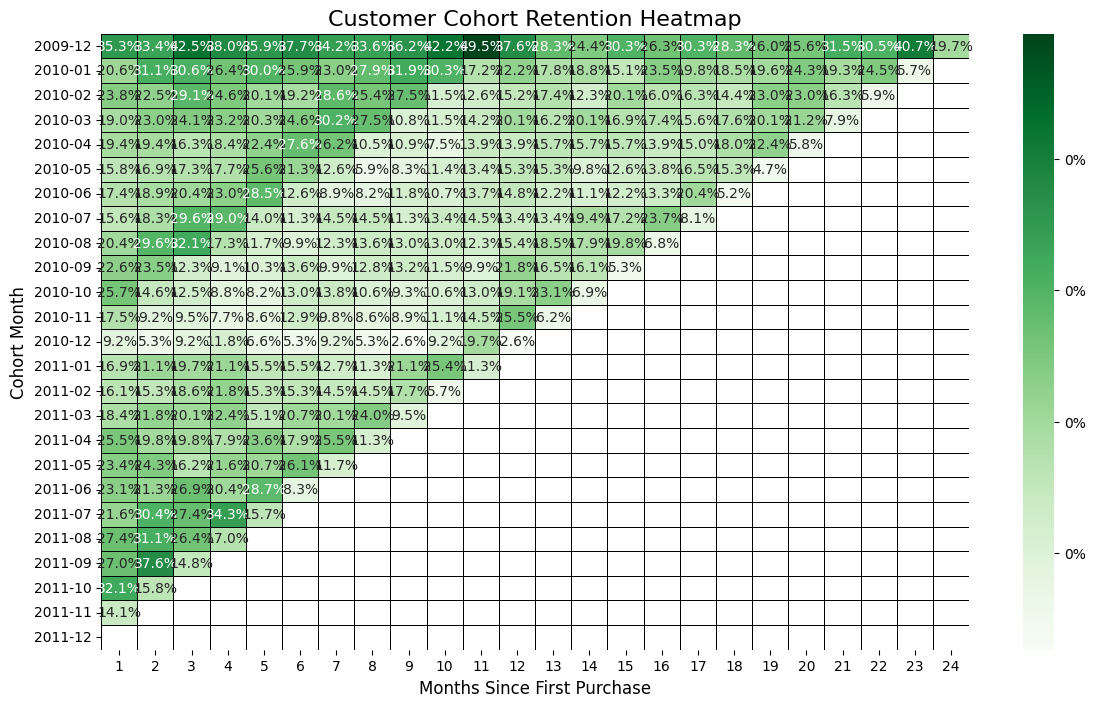


Average Retention Rate:
Month 1: 21.17%
Month 2: 21.92%
Month 3: 21.62%


In [9]:
# Make a copy of the retention table to avoid modifying the original string-formatted table
plot_retention_table = retention_table.copy()

# Convert string percentages to float (e.g., "35.29%" -> 0.3529)
# and handle 'nan%' by coercing to NaN
for col in plot_retention_table.columns:
    plot_retention_table[col] = plot_retention_table[col].astype(str).str.replace('%', '', regex=False)
    plot_retention_table[col] = pd.to_numeric(plot_retention_table[col], errors='coerce') / 100

# Drop the CohortIndex 0 column for the heatmap, as it's always 100% and makes other values harder to visualize
# Keep a full table for calculating averages if needed
plot_data_for_heatmap = plot_retention_table.drop(columns=[0])

# 1. Plot using seaborn heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(
    plot_data_for_heatmap,
    annot=True,              # Show percentage values
    fmt=".1%",               # Format annotations to one decimal place as percentage
    cmap="Greens",           # Use 'Greens' colormap as high retention should be green
    linewidths=.5,           # Add lines between cells for better readability
    linecolor='black',
    cbar_kws={'format': '%.0f%%'} # Color bar formatting
)
plt.title("Customer Cohort Retention Heatmap", fontsize=16)
plt.xlabel("Months Since First Purchase", fontsize=12)
plt.ylabel("Cohort Month", fontsize=12)
plt.yticks(rotation=0)
plt.show()

# 2. Print the average retention rate at month 1, month 2, and month 3
# Using the full `plot_retention_table` which contains all cohort indices as proportions (0-1)
# We need to make sure these columns exist before trying to calculate the mean

avg_retention_month_1 = plot_retention_table[1].mean(skipna=True) if 1 in plot_retention_table.columns else float('nan')
avg_retention_month_2 = plot_retention_table[2].mean(skipna=True) if 2 in plot_retention_table.columns else float('nan')
avg_retention_month_3 = plot_retention_table[3].mean(skipna=True) if 3 in plot_retention_table.columns else float('nan')

print("\nAverage Retention Rate:")
print(f"Month 1: {avg_retention_month_1:.2%}")
print(f"Month 2: {avg_retention_month_2:.2%}")
print(f"Month 3: {avg_retention_month_3:.2%}")

In [10]:
import pandas as pd
import numpy as np

# Step 1: Set snapshot date
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Step 2: Build RFM dataframe
rfm_df = df.groupby('Customer ID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('Invoice', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

# Step 3: Recency — lower days = higher score (qcut works fine here)
rfm_df['R_Score'] = pd.qcut(rfm_df['Recency'], 4, labels=[4,3,2,1], duplicates='drop')

# Step 4: Frequency — use rank-based scoring to handle duplicate values
rfm_df['F_Score'] = pd.qcut(rfm_df['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])

# Step 5: Monetary — use rank-based scoring to handle duplicate values
rfm_df['M_Score'] = pd.qcut(rfm_df['Monetary'].rank(method='first'), 4, labels=[1,2,3,4])

# Step 6: Convert to int and calculate total RFM score
rfm_df['R_Score'] = rfm_df['R_Score'].astype(int)
rfm_df['F_Score'] = rfm_df['F_Score'].astype(int)
rfm_df['M_Score'] = rfm_df['M_Score'].astype(int)
rfm_df['RFM_Score'] = rfm_df['R_Score'] + rfm_df['F_Score'] + rfm_df['M_Score']

print(f"Total Customers: {len(rfm_df)}")
print(f"\nRFM Summary Statistics:")
print(rfm_df[['Recency','Frequency','Monetary','RFM_Score']].describe().round(2))
print(f"\nSample RFM Data:")
print(rfm_df.head(10))

Total Customers: 5878

RFM Summary Statistics:
       Recency  Frequency   Monetary  RFM_Score
count  5878.00    5878.00    5878.00    5878.00
mean    201.33       6.29    2955.90       7.51
std     209.34      13.01   14440.85       2.87
min       1.00       1.00       2.95       3.00
25%      26.00       1.00     342.28       5.00
50%      96.00       3.00     867.74       7.00
75%     380.00       7.00    2248.30      10.00
max     739.00     398.00  580987.04      12.00

Sample RFM Data:
   Customer ID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0      12346.0      326         12  77556.46        2        4        4   
1      12347.0        2          8   4921.53        4        4        4   
2      12348.0       75          5   2019.40        3        3        3   
3      12349.0       19          4   4428.69        4        3        4   
4      12350.0      310          1    334.40        2        1        1   
5      12351.0      375          1    300.93        2


--- Customer Segment Counts ---
Segment
Champions              1740
Need Attention         1165
At Risk                 757
Loyal Customers         744
Lost                    571
Potential Loyalists     459
Cant Lose Them          442
Name: count, dtype: int64


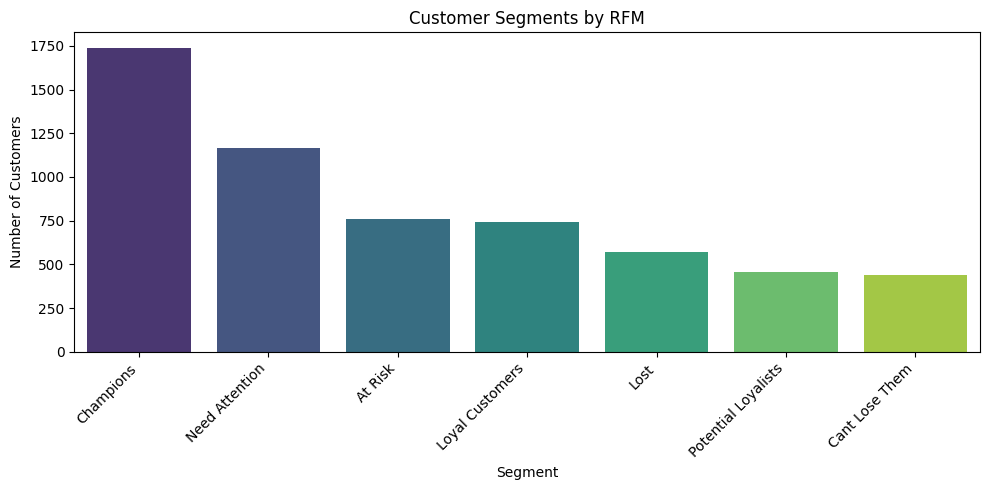

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a function called assign_segment
def assign_segment(row):
    if row['RFM_Score'] >= 10:
        return "Champions"
    elif row['RFM_Score'] >= 8 and row['R_Score'] >= 3:
        return "Loyal Customers"
    elif row['RFM_Score'] >= 8 and row['R_Score'] < 3:
        return "Cant Lose Them"
    elif row['RFM_Score'] >= 6 and row['R_Score'] >= 3:
        return "Potential Loyalists"
    elif row['RFM_Score'] >= 6 and row['R_Score'] < 3:
        return "At Risk"
    elif row['RFM_Score'] >= 4:
        return "Need Attention"
    else:
        return "Lost"

# 2. Apply this function to create a Segment column
rfm_df['Segment'] = rfm_df.apply(assign_segment, axis=1)

# 3. Print value counts of each segment
print("\n--- Customer Segment Counts ---")
segment_counts = rfm_df['Segment'].value_counts()
print(segment_counts)

# 4. Plot a bar chart of segment counts
plt.figure(figsize=(10, 5))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')
plt.title("Customer Segments by RFM")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45, ha='right') # Rotate x labels 45 degrees
plt.tight_layout()
plt.show()


--- RFM Segment Analysis ---
               Segment  Mean_Recency  Mean_Frequency  Mean_Monetary  Customer_Count
2            Champions         37.20           15.22        8056.42            1740
1       Cant Lose Them        247.57            5.91        2440.99             442
4      Loyal Customers         38.76            3.52        1077.72             744
0              At Risk        316.16            3.04        1015.60             757
6  Potential Loyalists         43.67            1.66         433.85             459
5       Need Attention        350.75            1.39         350.47            1165
3                 Lost        547.16            1.00         174.53             571


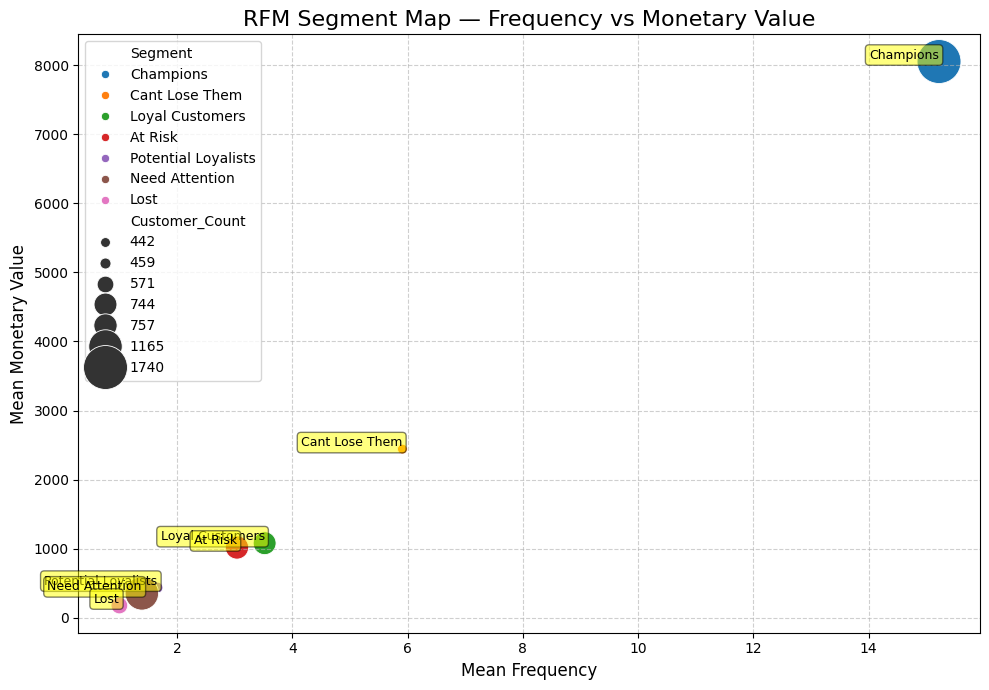

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by Segment and calculate mean Recency, mean Frequency, mean Monetary, and count of customers
rfm_segment_analysis = rfm_df.groupby('Segment').agg(
    Mean_Recency=('Recency', 'mean'),
    Mean_Frequency=('Frequency', 'mean'),
    Mean_Monetary=('Monetary', 'mean'),
    Customer_Count=('Customer ID', 'count')
).reset_index()

# 2. Round all values to 2 decimal places
rfm_segment_analysis = rfm_segment_analysis.round(2)

# 3. Sort by mean Monetary descending
rfm_segment_analysis = rfm_segment_analysis.sort_values(by='Mean_Monetary', ascending=False)

# 4. Print the full segment summary table
print("\n--- RFM Segment Analysis ---")
print(rfm_segment_analysis.to_string())

# 5. Plot a scatter plot
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=rfm_segment_analysis,
    x='Mean_Frequency',
    y='Mean_Monetary',
    size='Customer_Count', # Size of dots proportional to customer count
    hue='Segment',         # Each segment a different color
    sizes=(50, 1000),      # Adjust min/max size of dots
    legend='full'          # Show full legend for segments
)

# Label each dot with the segment name
for i, row in rfm_segment_analysis.iterrows():
    plt.text(row['Mean_Frequency'], row['Mean_Monetary'], row['Segment'],
             fontsize=9, ha='right', va='bottom',
             bbox=dict(boxstyle="round,pad=0.3", fc='yellow', alpha=0.5))

plt.title("RFM Segment Map — Frequency vs Monetary Value", fontsize=16)
plt.xlabel("Mean Frequency", fontsize=12)
plt.ylabel("Mean Monetary Value", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


--- Churn Class Distribution ---
         Count  Percentage
Churned                   
Churned   2989   50.850629
Active    2889   49.149371


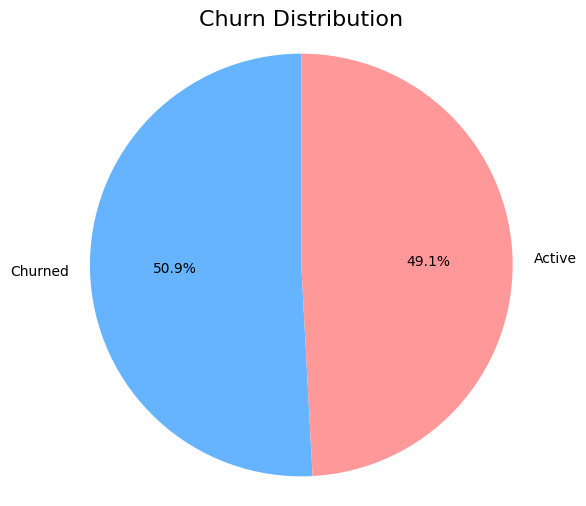

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define churned customers as those with Recency > 90 days
# Create a binary column called Churned (1=churned, 0=active)
rfm_df['Churned'] = (rfm_df['Recency'] > 90).astype(int)

# 2. Print class distribution and percentage of churned vs active
print("\n--- Churn Class Distribution ---")
churn_counts = rfm_df['Churned'].value_counts()
churn_percentages = rfm_df['Churned'].value_counts(normalize=True) * 100

churn_distribution = pd.DataFrame({
    'Count': churn_counts,
    'Percentage': churn_percentages
})
churn_distribution.index = churn_distribution.index.map({0: 'Active', 1: 'Churned'})
print(churn_distribution)

# 3. Plot a pie chart showing churned vs active customers
plt.figure(figsize=(6, 6))
plt.pie(churn_distribution['Count'],
        labels=churn_distribution.index,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#66b3ff', '#ff9999'])
plt.title("Churn Distribution", fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [14]:
print("--- Inspecting Variable Types ---")
print(rfm_df[['Recency', 'Frequency', 'Monetary', 'Churned']].dtypes)

print("\n--- Handling Missing Values ---")
# Check for missing values in the relevant columns
print(rfm_df[['Recency', 'Frequency', 'Monetary', 'Churned']].isnull().sum())

# Drop rows with any missing values if present (though unlikely after RFM calculation)
initial_rows = rfm_df.shape[0]
rfm_df_clean = rfm_df.dropna(subset=['Recency', 'Frequency', 'Monetary', 'Churned'])
if rfm_df_clean.shape[0] < initial_rows:
    print(f"Dropped {initial_rows - rfm_df_clean.shape[0]} rows due to missing values.")
else:
    print("No missing values found in specified columns.")


print("\n--- Encoding Categorical Variables ---")
# The specified features (Recency, Frequency, Monetary) are numerical.
# 'Churned' is already a binary numerical target variable (0 or 1).
# If there were other categorical features, one-hot encoding would be applied here.
print("No categorical features to encode among 'Recency', 'Frequency', 'Monetary', 'Churned'.")

# Define the feature set (X) and target variable (y)
X = rfm_df_clean[['Recency', 'Frequency', 'Monetary']]
y = rfm_df_clean['Churned']

print("\n--- Target Variable and Predictor Set Defined ---")
print(f"Predictor set (X) shape: {X.shape}")
print(f"Target variable (y) shape: {y.shape}")
print("First 5 rows of X:")
print(X.head())
print("First 5 values of y:")
print(y.head())

--- Inspecting Variable Types ---
Recency        int64
Frequency      int64
Monetary     float64
Churned        int64
dtype: object

--- Handling Missing Values ---
Recency      0
Frequency    0
Monetary     0
Churned      0
dtype: int64
No missing values found in specified columns.

--- Encoding Categorical Variables ---
No categorical features to encode among 'Recency', 'Frequency', 'Monetary', 'Churned'.

--- Target Variable and Predictor Set Defined ---
Predictor set (X) shape: (5878, 3)
Target variable (y) shape: (5878,)
First 5 rows of X:
   Recency  Frequency  Monetary
0      326         12  77556.46
1        2          8   4921.53
2       75          5   2019.40
3       19          4   4428.69
4      310          1    334.40
First 5 values of y:
0    1
1    0
2    0
3    0
4    1
Name: Churned, dtype: int64


In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import pandas as pd
import numpy as np

# Ensure X and y are available from the previous step
# X = rfm_df_clean[['Recency', 'Frequency', 'Monetary']]
# y = rfm_df_clean['Churned']

print(f"Dataset shape: X={X.shape}, y={y.shape}\n")

# Define the models to compare
# Using pipelines to ensure scaling is done within each fold of cross-validation
models = {
    'LR_Default': Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(random_state=42, solver='liblinear')) # liblinear supports L1/L2
    ]),
    'LR_L1_StrongReg': Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(penalty='l1', C=0.1, random_state=42, solver='liblinear')) # Strong L1 regularization
    ]),
    'LR_L2_WeakReg': Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(penalty='l2', C=10.0, random_state=42, solver='liblinear')) # Weak L2 regularization
    ]),
    'LR_L2_StrongReg': Pipeline([
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(penalty='l2', C=0.1, random_state=42, solver='liblinear')) # Strong L2 regularization
    ])
}

# Define cross-validation strategy
# StratifiedKFold is good for imbalanced datasets, though here it's roughly 50/50
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Metrics to collect
scoring = ['accuracy', 'precision', 'recall', 'roc_auc']

results = {}

print("--- Model Comparison with Cross-Validation ---\n")
for name, model_pipeline in models.items():
    print(f"Evaluating {name}...")
    cv_results = cross_validate(model_pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    results[name] = {
        'accuracy_mean': np.mean(cv_results['test_accuracy']),
        'accuracy_std': np.std(cv_results['test_accuracy']),
        'precision_mean': np.mean(cv_results['test_precision']),
        'precision_std': np.std(cv_results['test_precision']),
        'recall_mean': np.mean(cv_results['test_recall']),
        'recall_std': np.std(cv_results['test_recall']),
        'roc_auc_mean': np.mean(cv_results['test_roc_auc']),
        'roc_auc_std': np.std(cv_results['test_roc_auc'])
    }
    print(f"  Accuracy: {results[name]['accuracy_mean']:.3f} (+/- {results[name]['accuracy_std']:.3f})")
    print(f"  Precision: {results[name]['precision_mean']:.3f} (+/- {results[name]['precision_std']:.3f})")
    print(f"  Recall: {results[name]['recall_mean']:.3f} (+/- {results[name]['recall_std']:.3f})")
    print(f"  ROC-AUC: {results[name]['roc_auc_mean']:.3f} (+/- {results[name]['roc_auc_std']:.3f})\n")

print("--- Summary of All Model Variants ---\n")
# Convert results to a DataFrame for better readability
results_df = pd.DataFrame(results).T
results_df = results_df.round(3)
print(results_df)

Dataset shape: X=(5878, 3), y=(5878,)

--- Model Comparison with Cross-Validation ---

Evaluating LR_Default...
  Accuracy: 0.986 (+/- 0.005)
  Precision: 1.000 (+/- 0.000)
  Recall: 0.972 (+/- 0.010)
  ROC-AUC: 1.000 (+/- 0.000)

Evaluating LR_L1_StrongReg...
  Accuracy: 0.986 (+/- 0.005)
  Precision: 1.000 (+/- 0.000)
  Recall: 0.972 (+/- 0.010)
  ROC-AUC: 1.000 (+/- 0.000)

Evaluating LR_L2_WeakReg...
  Accuracy: 0.996 (+/- 0.001)
  Precision: 1.000 (+/- 0.000)
  Recall: 0.992 (+/- 0.003)
  ROC-AUC: 1.000 (+/- 0.000)

Evaluating LR_L2_StrongReg...
  Accuracy: 0.962 (+/- 0.007)
  Precision: 1.000 (+/- 0.000)
  Recall: 0.925 (+/- 0.014)
  ROC-AUC: 1.000 (+/- 0.000)

--- Summary of All Model Variants ---

                 accuracy_mean  accuracy_std  precision_mean  precision_std  \
LR_Default               0.986         0.005             1.0            0.0   
LR_L1_StrongReg          0.986         0.005             1.0            0.0   
LR_L2_WeakReg            0.996         0.001    

In [16]:
import matplotlib.pyplot as plt

# List of figure filenames in the order they were generated
figure_filenames = [
    'monthly_revenue.png',
    'top_products.png',
    'top_countries.png',
    'cohort_heatmap.png',
    'rfm_segments.png',
    'rfm_scatter.png',
    'churn_distribution.png'
]

# Iterate through figures and save them
for i, filename in enumerate(figure_filenames):
    # Matplotlib figure numbers start from 1, so add 1 to the index
    fig_num = i + 1
    try:
        # Activate the figure to be saved
        fig = plt.figure(fig_num)
        fig.savefig(filename, dpi=150, bbox_inches='tight')
        print(f"Saved {filename}")
    except Exception as e:
        print(f"Error saving {filename} (Figure {fig_num}): {e}")

print("All charts saved")

Saved monthly_revenue.png
Saved top_products.png
Saved top_countries.png
Saved cohort_heatmap.png
Saved rfm_segments.png
Saved rfm_scatter.png
Saved churn_distribution.png
All charts saved


<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [22]:
# Install reportlab
import subprocess
subprocess.run(['pip', 'install', 'reportlab', '-q'])

from reportlab.lib.pagesizes import A4
from reportlab.lib import colors
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import inch
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image, Table, TableStyle, PageBreak
from reportlab.lib.enums import TA_CENTER, TA_LEFT
from datetime import date
import os

# ── Page setup ──────────────────────────────────────────────────────────────
pdf_path = "Ecommerce_Analytics_Report.pdf"
doc = SimpleDocTemplate(pdf_path, pagesize=A4,
                        rightMargin=50, leftMargin=50,
                        topMargin=60, bottomMargin=60)

# ── Styles ───────────────────────────────────────────────────────────────────
base_styles = getSampleStyleSheet()

title_style = ParagraphStyle('ReportTitle', fontSize=24, textColor=colors.HexColor('#1B5E20'),
                              alignment=TA_CENTER, spaceAfter=12, fontName='Helvetica-Bold')
subtitle_style = ParagraphStyle('ReportSubtitle', fontSize=14, textColor=colors.HexColor('#2E7D32'),
                                 alignment=TA_CENTER, spaceAfter=8, fontName='Helvetica')
date_style = ParagraphStyle('ReportDate', fontSize=11, textColor=colors.grey,
                             alignment=TA_CENTER, spaceAfter=6, fontName='Helvetica-Oblique')
section_style = ParagraphStyle('SectionHead', fontSize=16, textColor=colors.HexColor('#1B5E20'),
                                spaceAfter=10, spaceBefore=20, fontName='Helvetica-Bold')
body_style = ParagraphStyle('BodyText', fontSize=11, textColor=colors.black,
                             spaceAfter=8, fontName='Helvetica', leading=16)
bullet_style = ParagraphStyle('BulletText', fontSize=11, textColor=colors.black,
                               spaceAfter=6, fontName='Helvetica', leftIndent=20, leading=14)
caption_style = ParagraphStyle('CaptionText', fontSize=9, textColor=colors.grey,
                                alignment=TA_CENTER, spaceAfter=10, fontName='Helvetica-Oblique')

# ── Helper to add image safely ────────────────────────────────────────────────
def add_image(story, filename, width=6*inch, height=3.5*inch):
    if os.path.exists(filename):
        story.append(Image(filename, width=width, height=height))
        story.append(Paragraph(f"Figure: {filename.replace('.png','').replace('_',' ').title()}", caption_style))
        story.append(Spacer(1, 12))
    else:
        story.append(Paragraph(f"[Chart not found: {filename}]", body_style))

# ── Build story ───────────────────────────────────────────────────────────────
story = []

# Cover Page
story.append(Spacer(1, 1.5*inch))
story.append(Paragraph("E-Commerce Customer Analytics Report", title_style))
story.append(Spacer(1, 0.2*inch))
story.append(Paragraph("Retail Transaction Analysis — Cohort, RFM & Churn", subtitle_style))
story.append(Spacer(1, 0.1*inch))
story.append(Paragraph(f"Date: {date.today().strftime('%B %d, %Y')}", date_style))
story.append(Spacer(1, 0.1*inch))
story.append(Paragraph("Dataset: Online Retail II — UCI Machine Learning Repository", date_style))
story.append(PageBreak())

# Section 1 — Business KPIs
story.append(Paragraph("1. Business KPIs", section_style))
story.append(Paragraph(
    "This section presents key revenue metrics derived from transaction data including "
    "monthly revenue trends, top performing products, and top international markets.",
    body_style))
story.append(Spacer(1, 10))
add_image(story, 'monthly_revenue.png')
add_image(story, 'top_products.png')
add_image(story, 'top_countries.png')
story.append(PageBreak())

# Section 2 — Cohort Retention
story.append(Paragraph("2. Cohort Retention Analysis", section_style))
story.append(Paragraph(
    "Customers are grouped by their first purchase month and tracked over subsequent months "
    "to measure how many return. This reveals whether retention is improving over time.",
    body_style))
story.append(Spacer(1, 6))

# Pull retention numbers dynamically if available
try:
    m1 = retention_table.iloc[:, 1].mean() * 100
    m2 = retention_table.iloc[:, 2].mean() * 100
    m3 = retention_table.iloc[:, 3].mean() * 100
    story.append(Paragraph(f"• Average Month 1 Retention Rate: {m1:.1f}%", bullet_style))
    story.append(Paragraph(f"• Average Month 2 Retention Rate: {m2:.1f}%", bullet_style))
    story.append(Paragraph(f"• Average Month 3 Retention Rate: {m3:.1f}%", bullet_style))
except:
    story.append(Paragraph("• Retention rates calculated from cohort analysis above.", bullet_style))

story.append(Spacer(1, 10))
add_image(story, 'cohort_heatmap.png', width=6.5*inch, height=4*inch)
story.append(PageBreak())

# Section 3 — RFM Segmentation
story.append(Paragraph("3. RFM Customer Segmentation", section_style))
story.append(Paragraph(
    "Every customer is scored on Recency, Frequency and Monetary value and grouped into "
    "actionable segments. This enables targeted marketing and retention strategies.",
    body_style))
story.append(Spacer(1, 10))
add_image(story, 'rfm_segments.png')
add_image(story, 'rfm_scatter.png')

# RFM summary table
try:
    seg_summary = rfm_df.groupby('Segment').agg(
        Customer_Count=('Recency', 'count'),
        Avg_Monetary=('Monetary', 'mean'),
        Avg_Recency=('Recency', 'mean')
    ).round(2).reset_index().sort_values('Avg_Monetary', ascending=False)

    table_data = [['Segment', 'Customers', 'Avg Spend (£)', 'Avg Recency (days)']]
    for _, row in seg_summary.iterrows():
        table_data.append([
            str(row['Segment']),
            str(int(row['Customer_Count'])),
            f"£{row['Avg_Monetary']:,.0f}",
            f"{row['Avg_Recency']:.0f} days"
        ])

    t = Table(table_data, colWidths=[2*inch, 1.2*inch, 1.5*inch, 1.8*inch])
    t.setStyle(TableStyle([
        ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#1B5E20')),
        ('TEXTCOLOR', (0,0), (-1,0), colors.white),
        ('FONTNAME', (0,0), (-1,0), 'Helvetica-Bold'),
        ('FONTSIZE', (0,0), (-1,-1), 10),
        ('ALIGN', (0,0), (-1,-1), 'CENTER'),
        ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.HexColor('#F1F8E9'), colors.white]),
        ('GRID', (0,0), (-1,-1), 0.5, colors.grey),
        ('BOTTOMPADDING', (0,0), (-1,-1), 8),
        ('TOPPADDING', (0,0), (-1,-1), 8),
    ]))
    story.append(Spacer(1, 10))
    story.append(t)
except Exception as e:
    story.append(Paragraph(f"Segment table could not be generated: {e}", body_style))

story.append(PageBreak())

# Section 4 — Churn Prediction
story.append(Paragraph("4. Churn Prediction", section_style))
story.append(Paragraph(
    "A logistic regression model was trained to predict customer churn based on "
    "Recency, Frequency and Monetary features. Customers inactive for 90+ days "
    "were labelled as churned.",
    body_style))
story.append(Spacer(1, 10))
add_image(story, 'churn_distribution.png', width=4*inch, height=3*inch)

story.append(Spacer(1, 10))
story.append(Paragraph("• Model: Logistic Regression with cross-validation", bullet_style))
story.append(Paragraph("• Features used: Recency, Frequency, Monetary Value", bullet_style))
story.append(Paragraph("• Target Variable: Churned (1 = churned, 0 = active)", bullet_style))

# ── Build PDF ─────────────────────────────────────────────────────────────────
def add_footer(canvas, doc):
    canvas.saveState()
    canvas.setFont('Helvetica', 8)
    canvas.setFillColor(colors.grey)
    canvas.drawString(50, 30, "Confidential — Internal Use")
    canvas.drawRightString(A4[0] - 50, 30, f"Page {doc.page}")
    canvas.restoreState()

doc.build(story, onFirstPage=add_footer, onLaterPages=add_footer)
print("Report generated successfully!")
print(f"Saved as: {pdf_path}")

Report generated successfully!
Saved as: Ecommerce_Analytics_Report.pdf


In [23]:
from google.colab import files

files_to_download = [
    'Ecommerce_Analytics_Report.pdf',
    'monthly_revenue.png',
    'cohort_heatmap.png',
    'rfm_segments.png'
]

for filename in files_to_download:
  try:
    files.download(filename)
  except Exception as e:
    print(f"Error downloading {filename}: {e}")

print("All files downloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All files downloaded
